### ***727723EUAI109 : Sanjay M***

### ***Practice : 2***

In [6]:
import pandas as pd

df = pd.read_csv('../Mall_Customers.csv')
print(df.shape)
df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Handle missing values
df.dropna(inplace=True)

# Encode 'Gender' column
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Select features for clustering
X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape after preprocessing: {X_scaled.shape}")

Shape after preprocessing: (200, 4)


In [8]:
from sklearn.cluster import KMeans, AgglomerativeClustering

# KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=5, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)

print("KMeans cluster counts:")
print(pd.Series(kmeans_labels).value_counts().sort_index())
print("\nAgglomerative cluster counts:")
print(pd.Series(agglo_labels).value_counts().sort_index())

KMeans cluster counts:
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

Agglomerative cluster counts:
0    61
1    39
2    33
3    38
4    29
Name: count, dtype: int64


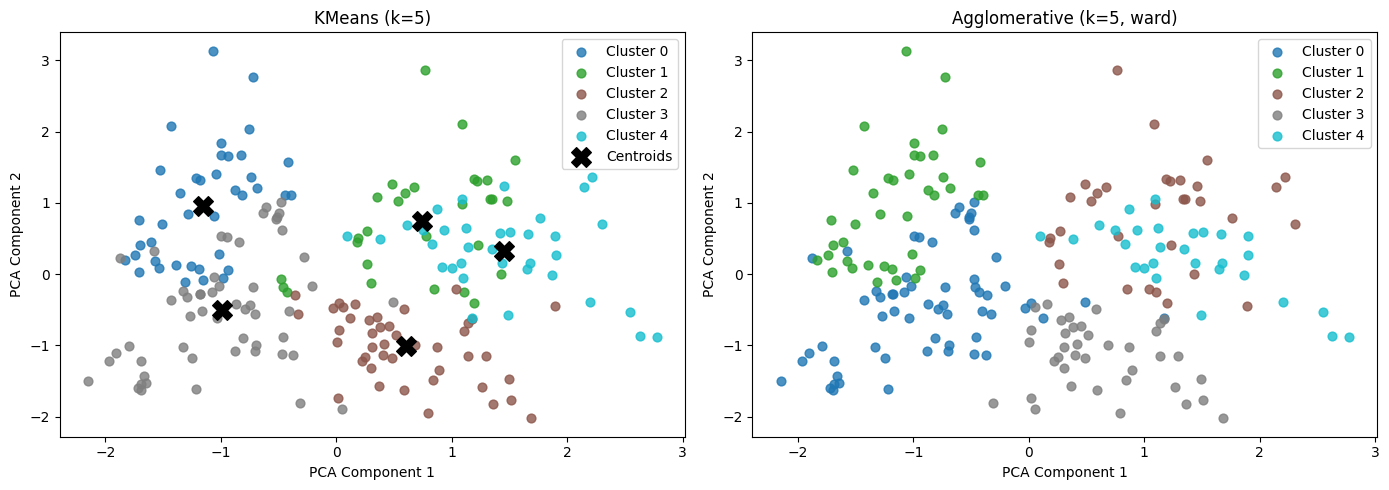

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

colors = plt.cm.tab10(np.linspace(0, 1, 5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(axes,
                              [kmeans_labels, agglo_labels],
                              ['KMeans (k=5)', 'Agglomerative (k=5, ward)']):
    for i in range(5):
        pts = X_pca[labels == i]
        ax.scatter(pts[:, 0], pts[:, 1], s=40, color=colors[i], label=f'Cluster {i}', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.legend()

# Mark KMeans centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=200, c='black', marker='X', label='Centroids', zorder=5)
axes[0].legend()

plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import silhouette_score

km_score = silhouette_score(X_scaled, kmeans_labels)
ag_score = silhouette_score(X_scaled, agglo_labels)

print(f"KMeans Silhouette Score       : {km_score:.4f}")
print(f"Agglomerative Silhouette Score: {ag_score:.4f}")

better = 'KMeans' if km_score > ag_score else 'Agglomerative'
print(f"\nBetter model: {better}")
print("Interpretation: A higher silhouette score indicates better-defined, well-separated clusters.")

KMeans Silhouette Score       : 0.3041
Agglomerative Silhouette Score: 0.2870

Better model: KMeans
Interpretation: A higher silhouette score indicates better-defined, well-separated clusters.
